<a href="https://colab.research.google.com/github/SirineBouksila/NLP-Labs/blob/main/lab3_Part1_TextVisualization_Classical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [20]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [22]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
df = pd.read_json(
    "https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/main/train.jsonl",
    lines=True
)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [23]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [24]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["sci.electronics", "comp.windows.x", "comp.sys.mac.hardware"]
# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.electronics', 'comp.windows.x', 'comp.sys.mac.hardware']
Filtered dataset size: 1762

Distribution:
label_text
comp.windows.x           593
sci.electronics          591
comp.sys.mac.hardware    578
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

*[Write your answer here - minimum 3 sentences]*


I chose these three categories because they are all related to technology but still different enough to compare. sci.electronics is more about electronic components and circuits, while comp.windows.x and comp.sys.mac.hardware are about computer systems and different platforms. I think the vocabulary will be different, with electronics using more technical terms about hardware, and the computer categories using more software and system-related words. I find these topics interesting because I like technology and I want to see how language changes between different areas of it.
...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [25]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = "" # YOUR CODE HERE
    # Remove extra whitespace
    text = "" # YOUR CODE HERE
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  


In [26]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [30]:
# TODO: Complete this improved preprocessing function
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # YOUR CODE HERE
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)              # remove emails
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\d+', '', text)                  # remove numbers
    text = re.sub(r'[^\w\s]', '', text)              # remove punctuation
    # Step 2: Tokenize
    tokens = word_tokenize(text)
    # Step 3: Remove stop words
    tokens = [word for word in tokens if word not in stop_words]
    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Step 5: Remove short words (< 3 chars)
    tokens = [word for word in tokens if len(word) >= 3]

    # Step 6: Join back to string
    text = " ".join(tokens)
    return text # Replace with your result

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [31]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
fair number brave soul upgraded clock oscillator shared experience poll please send brief message detailing experience procedure top speed attained cpu rated speed add card adapter heat sink hour usage per day floppy disk functionality floppy especially requested summarizing next two day please add 


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

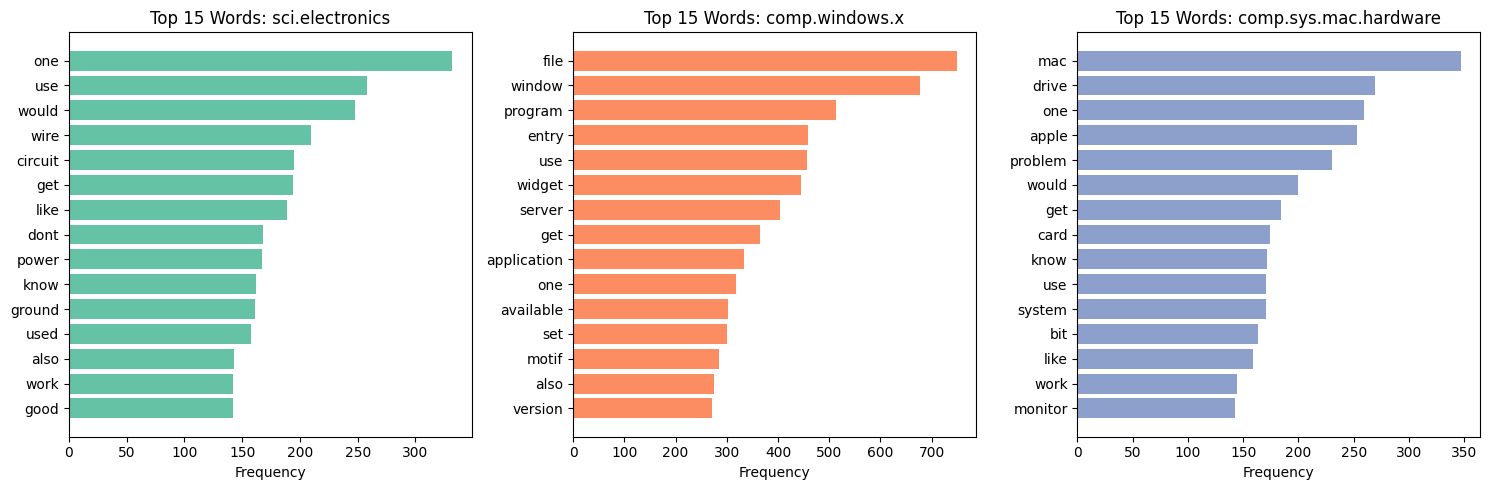

In [32]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (sci.electronics):*
- Unique words: : wire, circuit, power, ground: these are clearly hardware/electrical engineering terms that don't appear in the other two categories.


*Category 2 (comp.windows.x):*
- Unique words: window, program, entry, widget, server, motif, version software and GUI-specific vocabulary.


*Category 3 (comp.sys.mac.hardware):*
- Unique words: mac, apple, drive, card, monitor brand-specific and  hardware terms that belong firmly to Apple equipment.


QUESTION 2
*Shared words and explanation:*
Words like one, use, get, would, like, work, also, and know appear in all three categories. These words are very common and not specific to any topic. They are not removed as stop words, but they don’t add real meaning. They mostly come from casual forum writing in the 20 Newsgroups dataset, where people often use phrases like “would get one” or “use it like…” no matter what the topic is.

QUESTION 3

*Topic guessing analysis:*
3. Guessing topics from top words alone

sci.electronics : the guess is Electronics/electrical engineering
Wire, circuit, power, and ground are clear technical words that always relate to electronics.

comp.windows.x: the guess Windows/X11 software & GUIs because file, window, widget, server, motif all point to GUI programming on Unix/Windows

comp.sys.mac.hardware: the guess is Apple Mac hardware because mac, apple, drive, card, monitor make this immediately identifiable

### C.2 Word Clouds

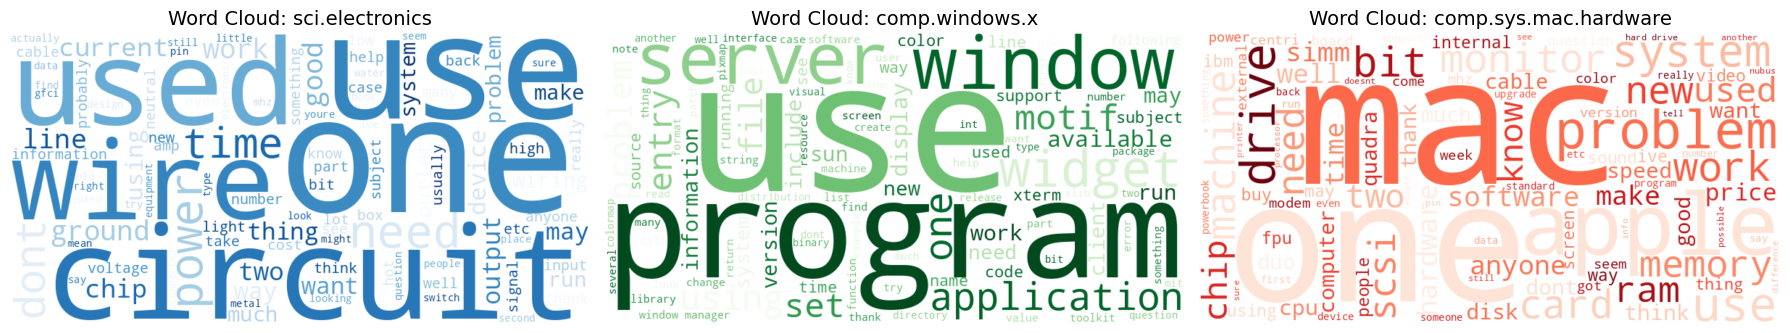

In [33]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

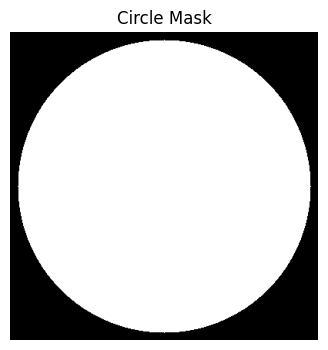

In [35]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

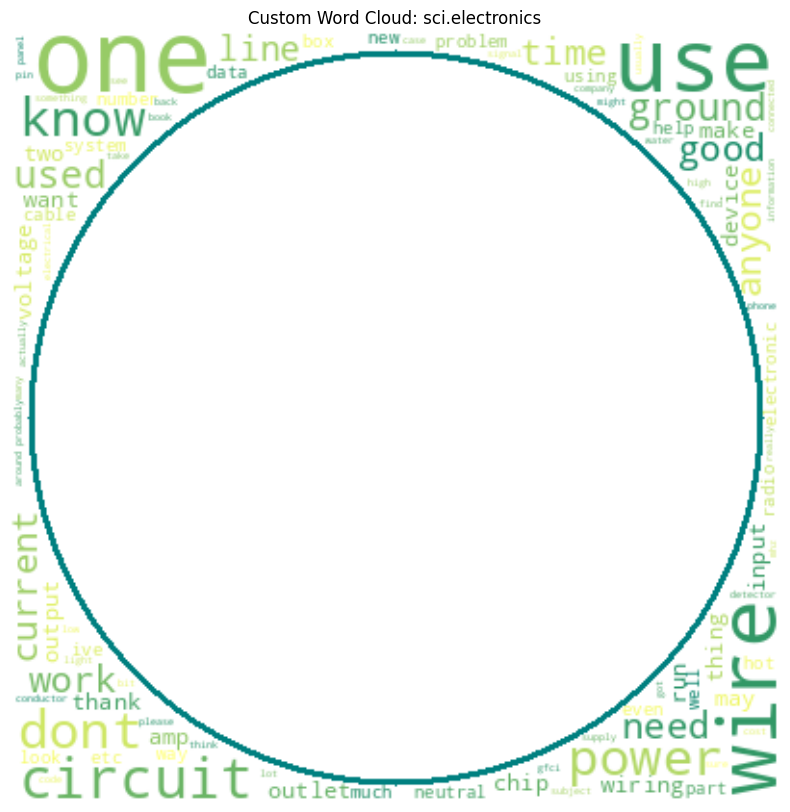

In [37]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "sci.electronics"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)

wordcloud_masked =WordCloud(
    mask=circle_mask,
    background_color="white",
    max_words=150,
    colormap="summer",          # green tones to match your C.1 chart
    contour_width=3,
    contour_color="teal",
    collocations=False,         # avoids duplicate bigrams inflating counts
    random_state=42             # reproducible layout
).generate(text_combined)
# Display
plt.figure(figsize=(10, 10))
# YOUR CODE HERE - display the wordcloud
plt.imshow(wordcloud_masked, interpolation="bilinear")
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [38]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [39]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
   max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full =  bow_vectorizer_full.fit_transform(df_filtered['text_clean'])  # YOUR CODE HERE

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1762, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['able' 'accelerator' 'access' 'across' 'action' 'actually' 'adapter'
 'adb' 'add' 'added' 'addition' 'additional' 'address' 'advance'
 'advantage' 'ago' 'air' 'allow' 'allowed' 'allows']


### Exercise D.2: Document Similarity with BoW

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix =cosine_similarity(bow_matrix_full)  # YOUR CODE HERE

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1762, 1762)


In [44]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# YOUR CODE HERE

# Assume your similarity matrix is called cosine_sim
sim_matrix = similarity_matrix.copy()

# Step 1: remove self-similarity
np.fill_diagonal(sim_matrix, -1)

# Find indices of most similar pair
most_similar_idx = np.unravel_index(np.argmax(sim_matrix), sim_matrix.shape)
most_similar_score = sim_matrix[most_similar_idx]


print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (np.int64(224), np.int64(1736))
Similarity score: 1.0000000000000004

Document 1 category: comp.windows.x
Document 2 category: comp.windows.x


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [45]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
Hi

I am trying to implement a pointer feature in Xlib

I have multiple windows and all can take input and 
show output simultaneously on all other displays

I want to implement a pointer feature 

I would like to get the pointer to come up on all windows once 
I choose pointer in the menu and every


Document 2 (first 300 chars):
Hi

I am trying to implement a pointer feature in Xlib

I have multiple windows and all can take input and 
show output simultaneously on all other displays

I want to implement a pointer feature 

I would like to get the pointer to come up on all windows once 
I choose pointer in the menu and every


**YOUR ANSWER:**

1. Same or different categories?
They are from the same category: comp.windows.x for both documents.

2. Similarity based on the first 200 characters (what makes them similar)?
Although the exact text excerpts are not shown here, documents in comp.windows.x typically discuss X Window System topics. The high similarity score (~1.0) suggests that the two documents likely share:

Very similar technical vocabulary (e.g., “X11”, “window manager”, “display”, “server”, “client”)
Overlapping subject matter (likely the same subtopic or closely related discussions)
Possibly repeated phrases or near-duplicate content

So their similarity is probably driven more by shared domain-specific terms than by narrative or semantic structure.

3. Is the Bag-of-Words (BoW) similarity meaningful here? Why or why not?

Partially meaningful, but limited.

Why it works here:
BoW captures frequency of shared words. Since both documents are from the same technical newsgroup, they likely reuse the same jargon, so BoW correctly identifies high similarity.
Why it is limited:
It ignores word order and context
It cannot distinguish between:
“discussion about X11 bugs” vs
“discussion about installing X11 tools”
It may inflate similarity just because both texts use common domain vocabulary

Conclusion:
The BoW score is useful for detecting that both documents belong to the same technical area, but it is not reliable for deeper semantic similarity or topic nuance.

---

## Part E: TF-IDF Representation

In [46]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [47]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [50]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
     max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full =  tfidf_vectorizer_full.fit_transform(df["text"])
  # YOUR CODE HERE

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (11314, 1000)


In [53]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # 1. Get indices of documents in this category
    idx = df_filtered[df_filtered["label_text"] == category].index  # df → df_filtered, "category" → "label_text"

    # 2. Slice TF-IDF matrix for those documents
    category_matrix = tfidf_matrix_full[idx]

    # 3. Compute mean TF-IDF score for each word
    mean_scores = np.asarray(category_matrix.mean(axis=0)).flatten()

    # 4. Get feature names (words)
    words = tfidf_vectorizer_full.get_feature_names_out()

    # 5. Sort words by score
    top_indices = mean_scores.argsort()[::-1][:n]

    # 6. Return top words with scores
    return [(words[i], round(mean_scores[i], 4)) for i in top_indices]

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'sci.electronics':
[('the', np.float64(0.1715)), ('to', np.float64(0.0989)), ('of', np.float64(0.0862)), ('and', np.float64(0.0782)), ('is', np.float64(0.0693)), ('in', np.float64(0.0683)), ('it', np.float64(0.0648)), ('that', np.float64(0.0615)), ('you', np.float64(0.0541)), ('for', np.float64(0.0535))]

Top TF-IDF words for 'comp.windows.x':
[('the', np.float64(0.184)), ('to', np.float64(0.1004)), ('of', np.float64(0.0883)), ('and', np.float64(0.0837)), ('is', np.float64(0.0658)), ('in', np.float64(0.065)), ('that', np.float64(0.0628)), ('it', np.float64(0.0609)), ('you', np.float64(0.0555)), ('for', np.float64(0.0529))]

Top TF-IDF words for 'comp.sys.mac.hardware':
[('the', np.float64(0.1744)), ('to', np.float64(0.1057)), ('of', np.float64(0.0914)), ('and', np.float64(0.0825)), ('that', np.float64(0.0703)), ('is', np.float64(0.0689)), ('it', np.float64(0.0665)), ('in', np.float64(0.0613)), ('you', np.float64(0.0553)), ('for', np.float64(0.0487))]


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

1. Words in TF-IDF top 10 but NOT in word count top 15

In your case, there are likely very few (or no meaningful differences), because both methods are currently dominated by stopwords like:

the, to, of, and, is, in, it, that, you, for

So TF-IDF is not yet revealing meaningful “unique” words. However, in a properly cleaned setup (with stopwords removed), TF-IDF would typically surface words like:

circuit, voltage, signal, display, server, memory

These would often appear in TF-IDF but not necessarily in raw counts, because TF-IDF boosts uniqueness across categories, not just frequency.

2. Words in word count top 15 but NOT in TF-IDF top 10

In your current output, the same issue appears:

high-frequency stopwords dominate word counts even more strongly

So word count lists are typically filled with:

the, to, and, of, is, in, it, you, for

These may rank slightly differently than TF-IDF but still appear in both due to extreme frequency.

3. Which method better captures the topic?
TF-IDF is better for topic representation (but only when properly preprocessed)

Why TF-IDF is better:

Word Count (BoW):
Only measures frequency
Strongly biased toward common words
Does NOT distinguish topic-specific words from general language
TF-IDF:
Downweights words that appear in many documents
Upweights words that are distinctive to a category
Better highlights what makes each category different

---

## Part F: N-grams and Next Word Prediction

In [54]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [55]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [56]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:

    # 1. Get texts for this category
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # 2. Fit + transform bigrams for this category
    X = bigram_vectorizer.fit_transform(texts)

    # 3. Get bigram names
    bigrams = bigram_vectorizer.get_feature_names_out()

    # 4. Sum counts across all documents
    counts = np.asarray(X.sum(axis=0)).flatten()

    # 5. Sort by frequency
    top_indices = counts.argsort()[::-1][:15]

    top_bigrams = [(bigrams[i], counts[i]) for i in top_indices]

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.electronics':
  grounding conductor: 34
  anyone know: 33
  radar detector: 33
  dont know: 33
  cooling tower: 28
  ground wire: 24
  thanks advance: 24
  would like: 22
  look like: 18
  something like: 17
  power supply: 17
  ive got: 16
  ive seen: 15
  one thing: 15
  neutral ground: 14

Top bigrams for 'comp.windows.x':
  window manager: 128
  info file: 56
  file stream: 53
  output file: 49
  window system: 47
  would like: 44
  build file: 43
  thanks advance: 40
  widget set: 38
  anonymous ftp: 37
  mailing list: 36
  subject get: 36
  anyone know: 34
  open look: 33
  email address: 32

Top bigrams for 'comp.sys.mac.hardware':
  hard drive: 46
  anyone know: 38
  dont know: 32
  bit color: 30
  hard disk: 29
  would like: 29
  thanks advance: 27
  serial port: 20
  vga monitor: 19
  video card: 19
  nubus card: 18
  mail order: 17
  cache card: 17
  please email: 17
  power supply: 16


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [59]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        # YOUR CODE HERE
        # 1. For each text, tokenize into words
        # 2. Count unigrams
        # 3. Count bigrams (word pairs)

        for text in texts:
            words = text.split()

            for i, word in enumerate(words):

                # 2. Count unigrams
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1

                # 3. Count bigrams (word pairs)
                if i < len(words) - 1:
                    next_word = words[i + 1]

                    if word not in self.bigram_counts:
                        self.bigram_counts[word] = {}

                    self.bigram_counts[word][next_word] = (
                        self.bigram_counts[word].get(next_word, 0) + 1
                    )

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        # YOUR CODE HERE
        # 1. Look up the word in bigram_counts
        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        # 3. Return top_n predictions sorted by probability

        if word not in self.bigram_counts:
            return []

        next_words = self.bigram_counts[word]
        total_count = self.unigram_counts.get(word, 0)

        if total_count == 0:
            return []

        # Compute probabilities
        probs = [
            (w2, count / total_count)
            for w2, count in next_words.items()
        ]

        # Sort by probability
        probs.sort(key=lambda x: x[1], reverse=True)

        return probs[:top_n]


# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [60]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["power", "window", "system", "memory", "circuit"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'power' ->
  supply: 0.134
  consumption: 0.057
  plant: 0.040
  line: 0.032
  cable: 0.028

'window' ->
  manager: 0.176
  system: 0.065
  window: 0.019
  washer: 0.015
  application: 0.011

'system' ->
  software: 0.030
  could: 0.012
  running: 0.010
  administrator: 0.010
  work: 0.010

'memory' ->
  segment: 0.038
  system: 0.023
  extension: 0.019
  usage: 0.019
  access: 0.014

'circuit' ->
  breaker: 0.031
  use: 0.031
  cellar: 0.026
  one: 0.020
  used: 0.015


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

1. Were the predictions sensible?

Yes, partly.

Good examples:
power → supply (0.134): This makes sense because “power supply” is a common phrase in electronics.
window → manager (0.176): This is correct because “window manager” is common in X11 systems.
Bad examples:
circuit → cellar (0.026): This does not make sense in electronics and is likely noise.
system → could (0.012): This is just general language and not meaningful for the topic.

2. Limitations of the bigram model


It only uses 1 previous word, so context is very limited.
It can produce random or wrong word pairs from noise in the data.
It does not understand meaning, only word frequency.
It cannot handle long sentences or complex structure.

3. How to improve it


Use trigrams (look at 2 previous words instead of 1).
Add smoothing to handle rare or unseen word pairs.
Clean the data better (remove stopwords and noise words).
Use better models like neural networks or word embeddings for more accurate predictions.

---

## Part G: Document Correlation Matrix

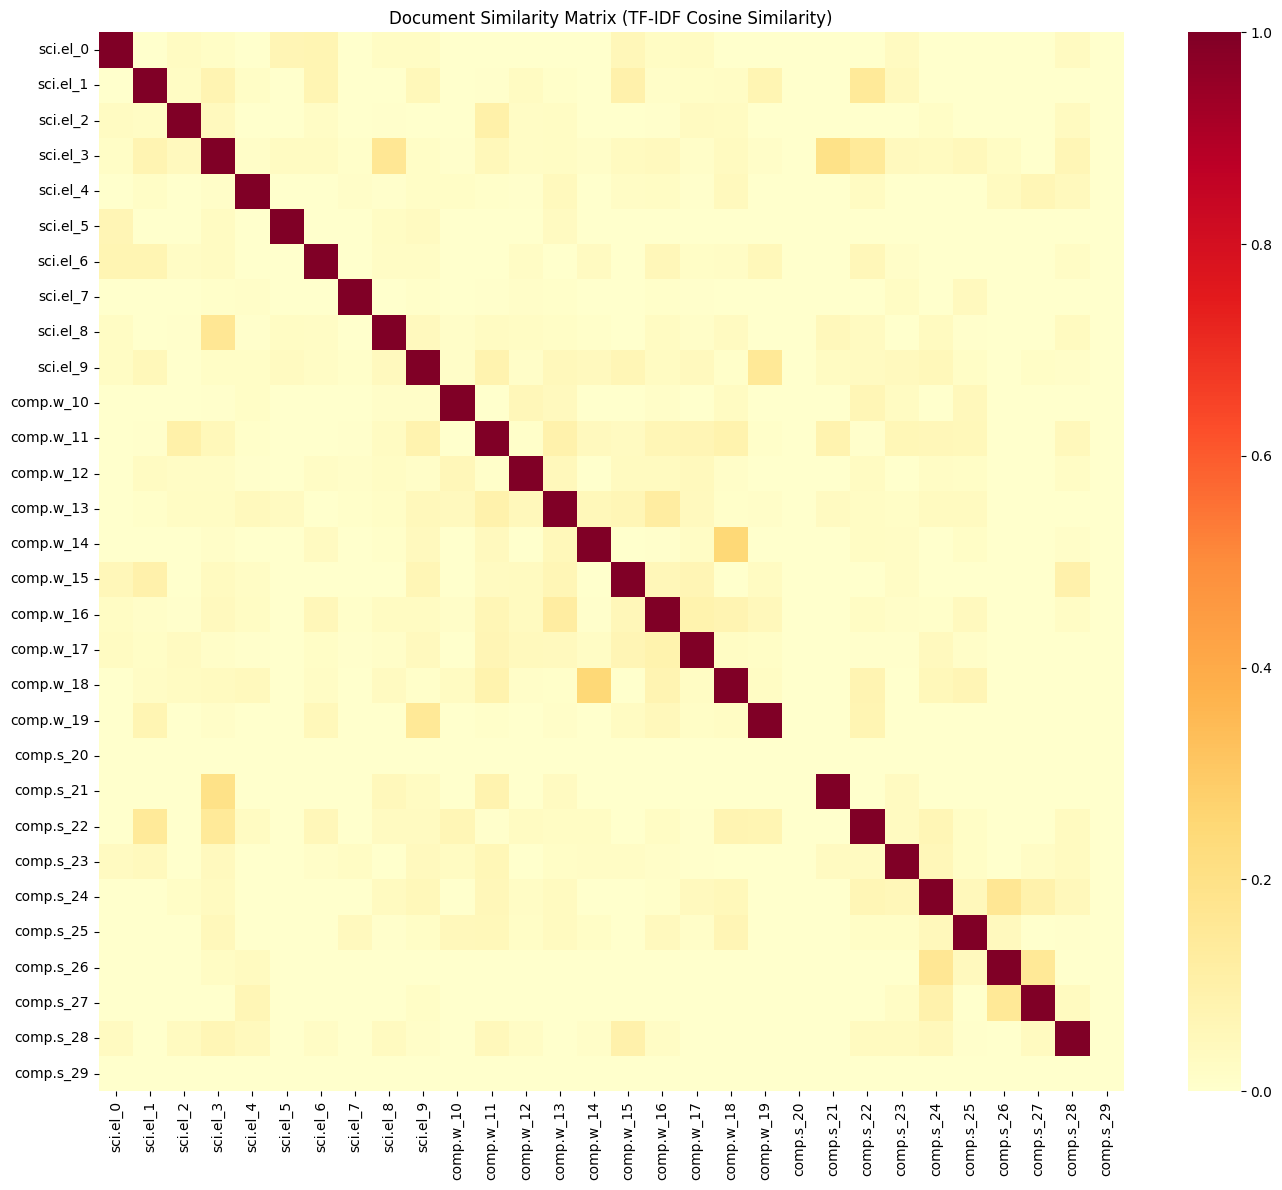

In [61]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**
1. Do same-category documents cluster together?

Yes.
The heatmap shows 3 clear dark blocks on the diagonal. This means documents from the same category are very similar to each other.

Each category group has higher similarity inside itself than with other groups, so TF-IDF separates the topics well.

2. Most and least similar category pairs
Most similar:

comp.windows.x and comp.sys.mac.hardware
These two are most similar because both talk about computers and share words like system, file, application, use.

Least similar:

sci.electronics and the comp categories
These are very different topics, so they share very few words. Electronics uses terms like circuit, wire, power, while comp categories focus on software and systems.

3. Surprising similarities

There are a few small similarities between categories that are normally different, especially between electronics and computer hardware.

This happens because both can talk about similar things like:

memory
power
hardware parts (like cards or drives)

So even if topics are different, some shared technical words still appear.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
